In [38]:
import numpy as np
import pandas as pd 
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt


## Merging/Organizing Dataset ##

In [ ]:
import os 
from functools import reduce

folder_path = r"C:\Personal Projects\HEEW-20250912\raw data 2"
dfs = [] #stores all processes building dataframes
for file in os.listdir(folder_path): #showing all the files in the folder
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)

        df = pd.read_csv(file_path)

        df = df[['Year', 'Month', 'Day', 'Hour', 'Weekday', 'Total Energy']]

        building_name = os.path.splitext(file)[0]
        df = df.rename(columns={'Total Energy': f'{building_name}'}) #extracts the file name (building name)

        dfs.append(df) #the dataframe would look something lie this: dfs = [df1, df2, df3, ..., df147]

final_df = reduce(
    lambda left, right: pd.merge(
        left, 
        right, 
        on = ['Year', 'Month', 'Day', 'Hour', 'Weekday'],
        how = 'outer'#outer means keeping all timestamps from all files
    ), #merges dataframe one by one - left being accumulated merged dataframe and the right being the next dataframe
    dfs
)

final_df = final_df.sort_values(by=['Year', 'Month', 'Day', 'Hour']) #sorts row by time

final_df.to_csv('total_energy_dataset.csv', index=False) #saves the dataframe as csv in the current working directory

print(final_df.head())
print(final_df.shape)
final_df.head()

   Year  Month  Day  Hour  Weekday  BN001_energy  BN002_energy  BN003_energy  \
0  2014      1    1     0        2           NaN          1.26          0.10   
1  2014      1    1     1        2           NaN          1.18          0.09   
2  2014      1    1     2        2           NaN          1.22          0.10   
3  2014      1    1     3        2           NaN          1.21          0.10   
4  2014      1    1     4        2           NaN          1.24          0.11   

   BN004_energy  BN005_energy  ...  BN142_energy  BN143_energy  BN144_energy  \
0          0.10          0.12  ...           NaN          0.17          0.14   
1          0.11          0.11  ...           NaN          0.17          0.13   
2          0.11          0.11  ...           NaN          0.17          0.13   
3          0.11          0.11  ...           NaN          0.17          0.13   
4          0.11          0.11  ...           NaN          0.17          0.13   

   BN145_energy  BN146_energy  BN147_e

,Year,Month,Day,Hour,Weekday,BN001_energy,BN002_energy,BN003_energy,BN004_energy,BN005_energy,...,BN142_energy,BN143_energy,BN144_energy,BN145_energy,BN146_energy,BN147_energy,CN01_energy,CN02_energy,CN03_energy,CN04_energy
0,2014,1,1,0,2,NaN,1.26,0.10,0.10,0.12,...,NaN,0.17,0.14,2.02,NaN,2.21,NaN,NaN,89.35,NaN
1,2014,1,1,1,2,NaN,1.18,0.09,0.11,0.11,...,NaN,0.17,0.13,2.04,NaN,2.26,NaN,NaN,86.41,NaN
2,2014,1,1,2,2,NaN,1.22,0.10,0.11,0.11,...,NaN,0.17,0.13,2.06,NaN,2.15,NaN,NaN,87.64,NaN
3,2014,1,1,3,2,NaN,1.21,0.10,0.11,0.11,...,NaN,0.17,0.13,2.09,NaN,2.20,NaN,NaN,88.72,NaN
4,2014,1,1,4,2,NaN,1.24,0.11,0.11,0.11,...,NaN,0.17,0.13,2.19,NaN,2.23,NaN,NaN,92.14,NaN


I combined the 147 building energy data into one dataset so that each building's total energy consumption could be analyzed together across the same timestamps

In [ ]:
## Declaring the new dataset that has been created above
datafile = r"C:\Personal Projects\EDA\total_energy_dataset.csv"
energy_raw = pd.read_csv(datafile)
print(energy_raw.shape)
energy_raw.head()


(78888, 156)


,Year,Month,Day,Hour,Weekday,BN001_energy,BN002_energy,BN003_energy,BN004_energy,BN005_energy,...,BN142_energy,BN143_energy,BN144_energy,BN145_energy,BN146_energy,BN147_energy,CN01_energy,CN02_energy,CN03_energy,CN04_energy
0,2014,1,1,0,2,NaN,1.26,0.10,0.10,0.12,...,NaN,0.17,0.14,2.02,NaN,2.21,NaN,NaN,89.35,NaN
1,2014,1,1,1,2,NaN,1.18,0.09,0.11,0.11,...,NaN,0.17,0.13,2.04,NaN,2.26,NaN,NaN,86.41,NaN
2,2014,1,1,2,2,NaN,1.22,0.10,0.11,0.11,...,NaN,0.17,0.13,2.06,NaN,2.15,NaN,NaN,87.64,NaN
3,2014,1,1,3,2,NaN,1.21,0.10,0.11,0.11,...,NaN,0.17,0.13,2.09,NaN,2.20,NaN,NaN,88.72,NaN
4,2014,1,1,4,2,NaN,1.24,0.11,0.11,0.11,...,NaN,0.17,0.13,2.19,NaN,2.23,NaN,NaN,92.14,NaN


In [ ]:
## Creating a time column ##
energy_raw['Time'] = pd.to_datetime(
    energy_raw[['Year', 'Month', 'Day', 'Hour']]
)
cols = ['Time'] + [col for col in energy_raw.columns if col != 'Time']
energy_raw = energy_raw[cols]


## Data types ##
energy_raw.dtypes

#energy_raw = energy_raw.drop(columns='DateTime')
# Dropping Year, Month, Day, Hour, Weekday for now
energy_raw = energy_raw.drop(columns=['Year', 'Month', 'Day', 'Hour'], errors='ignore')
energy_raw = energy_raw.drop(columns='Weekday', errors='ignore')


energy_raw.head()

,Time,BN001_energy,BN002_energy,BN003_energy,BN004_energy,BN005_energy,BN006_energy,BN007_energy,BN008_energy,BN009_energy,...,BN142_energy,BN143_energy,BN144_energy,BN145_energy,BN146_energy,BN147_energy,CN01_energy,CN02_energy,CN03_energy,CN04_energy
0,2014-01-01 00:00:00,NaN,1.26,0.10,0.10,0.12,0.04,0.02,0.31,0.17,...,NaN,0.17,0.14,2.02,NaN,2.21,NaN,NaN,89.35,NaN
1,2014-01-01 01:00:00,NaN,1.18,0.09,0.11,0.11,0.04,0.02,0.30,0.18,...,NaN,0.17,0.13,2.04,NaN,2.26,NaN,NaN,86.41,NaN
2,2014-01-01 02:00:00,NaN,1.22,0.10,0.11,0.11,0.05,0.02,0.30,0.18,...,NaN,0.17,0.13,2.06,NaN,2.15,NaN,NaN,87.64,NaN
3,2014-01-01 03:00:00,NaN,1.21,0.10,0.11,0.11,0.04,0.02,0.30,0.17,...,NaN,0.17,0.13,2.09,NaN,2.20,NaN,NaN,88.72,NaN
4,2014-01-01 04:00:00,NaN,1.24,0.11,0.11,0.11,0.05,0.02,0.29,0.17,...,NaN,0.17,0.13,2.19,NaN,2.23,NaN,NaN,92.14,NaN


In [42]:
##Summary Statistics##
summary_statistics = energy_raw.describe()
summary_statistics

,Time,BN001_energy,BN002_energy,BN003_energy,BN004_energy,BN005_energy,BN006_energy,BN007_energy,BN008_energy,BN009_energy,...,BN142_energy,BN143_energy,BN144_energy,BN145_energy,BN146_energy,BN147_energy,CN01_energy,CN02_energy,CN03_energy,CN04_energy
count,78888,56482.000000,78868.000000,78868.000000,78868.000000,78868.000000,78868.000000,78868.000000,78869.000000,78869.000000,...,44495.000000,78870.000000,78870.000000,78856.000000,76360.000000,7.887000e+04,0.0,0.0,78735.000000,0.0
mean,2018-07-02 11:30:00,2.327394,2.146126,0.138104,0.115401,0.208409,0.042656,0.037622,0.509782,0.367494,...,0.215814,0.781052,2.028479,1.144789,0.681547,5.581021e+28,NaN,NaN,171.873361,NaN
min,2014-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,NaN,NaN,0.000000,NaN
25%,2016-04-01 17:45:00,1.670000,1.350000,0.090000,0.080000,0.130000,0.020000,0.020000,0.340000,0.200000,...,0.060000,0.140000,0.820000,0.550000,0.330000,2.430000e+00,NaN,NaN,120.080000,NaN
50%,2018-07-02 11:30:00,2.210000,1.990000,0.120000,0.100000,0.170000,0.030000,0.030000,0.430000,0.330000,...,0.170000,0.340000,1.650000,0.950000,0.570000,4.290000e+00,NaN,NaN,159.630000,NaN
75%,2020-10-01 05:15:00,3.020000,2.810000,0.170000,0.140000,0.260000,0.050000,0.050000,0.670000,0.520000,...,0.330000,1.050000,2.650000,1.510000,0.850000,7.840000e+00,NaN,NaN,216.520000,NaN
max,2022-12-31 23:00:00,5.220000,6.780000,0.440000,0.390000,0.680000,0.170000,0.410000,1.140000,1.740000,...,1.200000,21.910000,13.750000,13.530000,23.670000,4.401752e+33,NaN,NaN,5058.910000,NaN
std,NaN,0.930721,0.954375,0.068165,0.050567,0.099927,0.025520,0.028708,0.202309,0.260098,...,0.187023,1.310619,1.655918,0.778601,1.175633,1.567363e+31,NaN,NaN,66.188636,NaN


In [ ]:
## Confirming we are not missing out on any timestamps within 1 hr interval by comparing the min and max dates and making sure we have number of timestamps 
# equal to count ##
full_date_range = pd.date_range(start="2014-01-01 00:00:00", end="2022-12-31 23:00:00", freq="1h")

## Check for duplicate time stamps ##
assert (full_date_range == energy_raw.Time).all() 

<Axes: xlabel='count', ylabel='Count'>

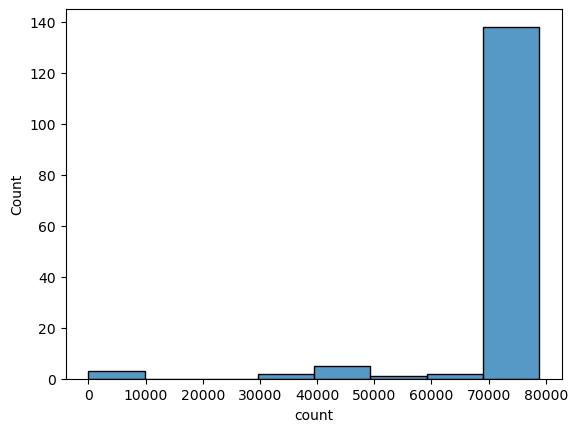

In [ ]:
## Creating Histogram on the number of data of each building ##
sns.histplot(summary_statistics.iloc[0, 1:], bins = 8)


In [45]:
## Checking for duplicate ##
energy_raw.duplicated().sum()

0

## Missing Value Analysis ##

In [46]:

energy_raw = energy_raw.set_index("Time")
energy_raw.head() # time becomes an index column from a regular column 

,BN001_energy,BN002_energy,BN003_energy,BN004_energy,BN005_energy,BN006_energy,BN007_energy,BN008_energy,BN009_energy,BN010_energy,...,BN142_energy,BN143_energy,BN144_energy,BN145_energy,BN146_energy,BN147_energy,CN01_energy,CN02_energy,CN03_energy,CN04_energy
Time,,,,,,,,,,,,,,,,,,,,,
2014-01-01 00:00:00,NaN,1.26,0.10,0.10,0.12,0.04,0.02,0.31,0.17,0.20,...,NaN,0.17,0.14,2.02,NaN,2.21,NaN,NaN,89.35,NaN
2014-01-01 01:00:00,NaN,1.18,0.09,0.11,0.11,0.04,0.02,0.30,0.18,0.21,...,NaN,0.17,0.13,2.04,NaN,2.26,NaN,NaN,86.41,NaN
2014-01-01 02:00:00,NaN,1.22,0.10,0.11,0.11,0.05,0.02,0.30,0.18,0.21,...,NaN,0.17,0.13,2.06,NaN,2.15,NaN,NaN,87.64,NaN
2014-01-01 03:00:00,NaN,1.21,0.10,0.11,0.11,0.04,0.02,0.30,0.17,0.21,...,NaN,0.17,0.13,2.09,NaN,2.20,NaN,NaN,88.72,NaN
2014-01-01 04:00:00,NaN,1.24,0.11,0.11,0.11,0.05,0.02,0.29,0.17,0.21,...,NaN,0.17,0.13,2.19,NaN,2.23,NaN,NaN,92.14,NaN


BN001_energy    0.284023
BN002_energy    0.000254
BN003_energy    0.000254
BN004_energy    0.000254
BN005_energy    0.000254
                  ...   
BN144_energy    0.000228
BN145_energy    0.000406
BN146_energy    0.032045
BN147_energy    0.000228
CN03_energy     0.001939
Length: 148, dtype: float64


<Axes: ylabel='Count'>

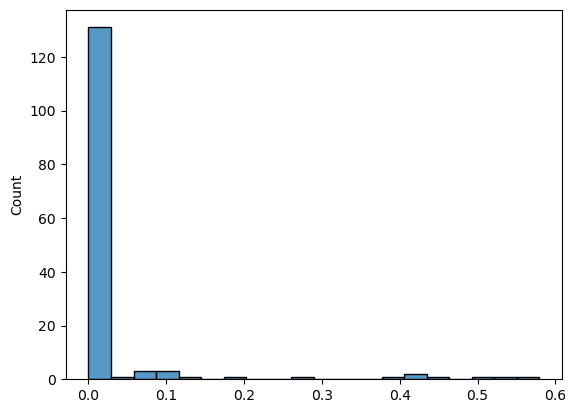

In [ ]:
## The diagram shows the spread of % of missing data for each building ##
perc_nan = energy_raw.isna().sum()/len(energy_raw) 
print(perc_nan)
sns.histplot(perc_nan, bins=20) 

In [ ]:
perc_nan.sort_values(ascending=True)



BN035_energy    0.000203
BN034_energy    0.000215
BN136_energy    0.000215
BN130_energy    0.000215
BN039_energy    0.000228
                  ...   
BN018_energy    0.523933
BN068_energy    0.579340
CN01_energy     1.000000
CN02_energy     1.000000
CN04_energy     1.000000
Length: 151, dtype: float64

nan perc for CN01, CN02, CN04 remains 100%

CN04_energy
CN02_energy
CN01_energy
BN068_energy
BN018_energy


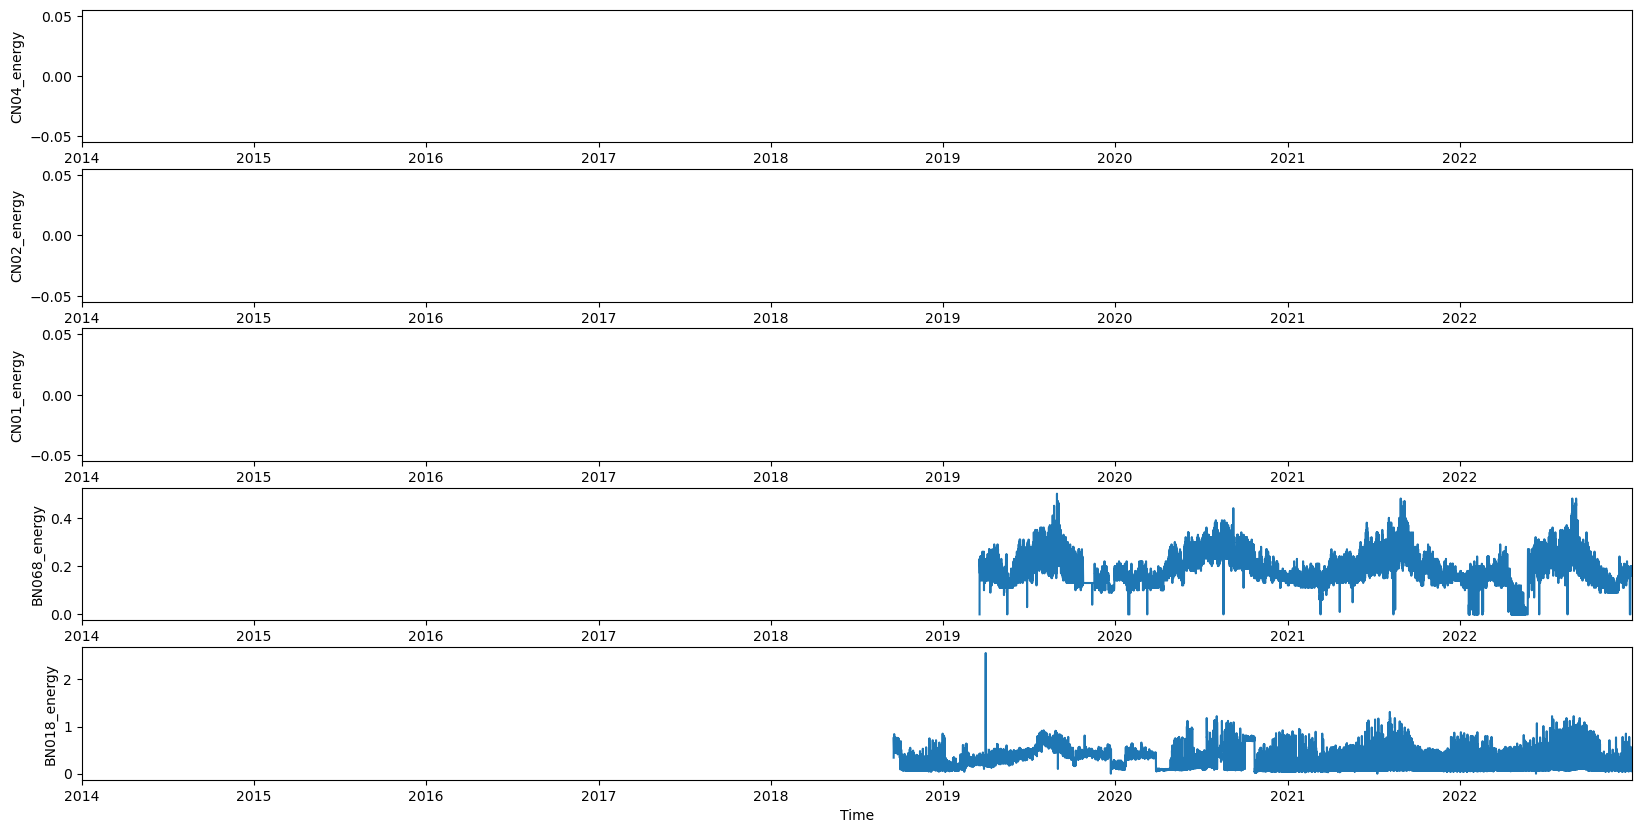

In [ ]:
low_value_meters = perc_nan.sort_values(ascending=False).index[0:5] #Selecting devices with highest % of missing values 
low_value_meters

fig, ax = plt.subplots(nrows=5, figsize=(20,10))
for i, column in enumerate(low_value_meters):
    print(column)
    plot1 = sns.lineplot(energy_raw[column], ax = ax[i])
    plot1.set_xlim(energy_raw.index.min(), energy_raw.index.max())


The figure shows how certain devices have no energy data at all and some have data starting a little before or after 2019 till the end of 2022

<Axes: xlabel='Time', ylabel='CN04_energy'>

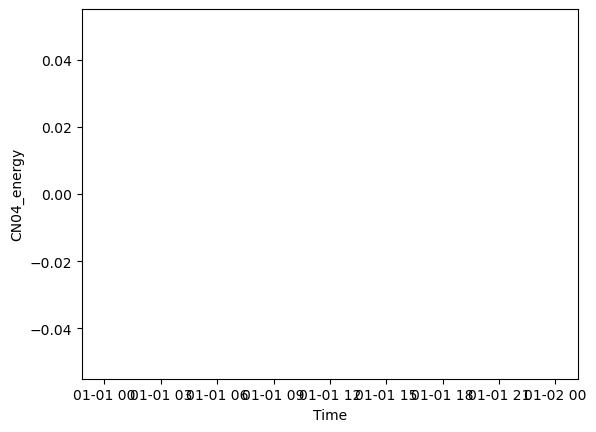

In [ ]:
## Deeply looking into the CN04, CN02 and CN01 energy dataset ##
sns.lineplot(energy_raw["CN04_energy"])
sns.lineplot(energy_raw["CN02_energy"])
sns.lineplot(energy_raw["CN01_energy"])



There is no energy data present for these devices.

In [ ]:
## Dropping devices that has no data ##
energy_raw = energy_raw.drop(columns=['CN01_energy', 'CN02_energy','CN04_energy'])
energy_raw.head()

,BN001_energy,BN002_energy,BN003_energy,BN004_energy,BN005_energy,BN006_energy,BN007_energy,BN008_energy,BN009_energy,BN010_energy,...,BN139_energy,BN140_energy,BN141_energy,BN142_energy,BN143_energy,BN144_energy,BN145_energy,BN146_energy,BN147_energy,CN03_energy
Time,,,,,,,,,,,,,,,,,,,,,
2014-01-01 00:00:00,NaN,1.26,0.10,0.10,0.12,0.04,0.02,0.31,0.17,0.20,...,0.0,0.75,0.29,NaN,0.17,0.14,2.02,NaN,2.21,89.35
2014-01-01 01:00:00,NaN,1.18,0.09,0.11,0.11,0.04,0.02,0.30,0.18,0.21,...,0.0,0.80,0.29,NaN,0.17,0.13,2.04,NaN,2.26,86.41
2014-01-01 02:00:00,NaN,1.22,0.10,0.11,0.11,0.05,0.02,0.30,0.18,0.21,...,0.0,0.68,0.30,NaN,0.17,0.13,2.06,NaN,2.15,87.64
2014-01-01 03:00:00,NaN,1.21,0.10,0.11,0.11,0.04,0.02,0.30,0.17,0.21,...,0.0,0.70,0.33,NaN,0.17,0.13,2.09,NaN,2.20,88.72
2014-01-01 04:00:00,NaN,1.24,0.11,0.11,0.11,0.05,0.02,0.29,0.17,0.21,...,0.0,0.72,0.33,NaN,0.17,0.13,2.19,NaN,2.23,92.14


## Correlation Analysis ## 

<Axes: >

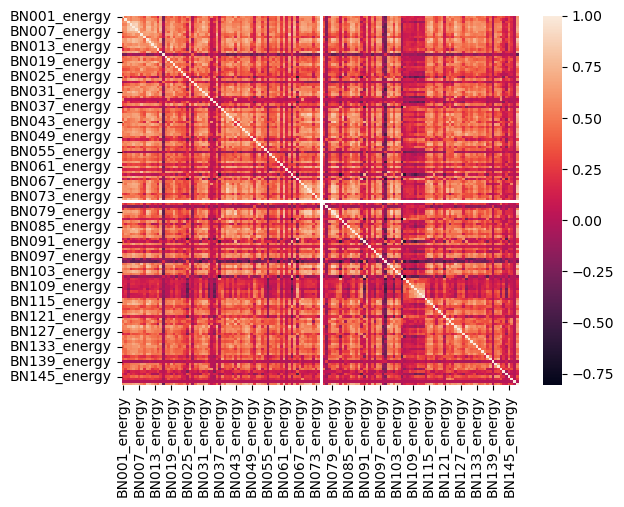

In [ ]:
## Heatmap to describe the correlation ##
corr_mat = energy_raw.corr()
sns.heatmap(corr_mat)


Strong positive correlation can be seen for the BN series of devices

<Axes: >

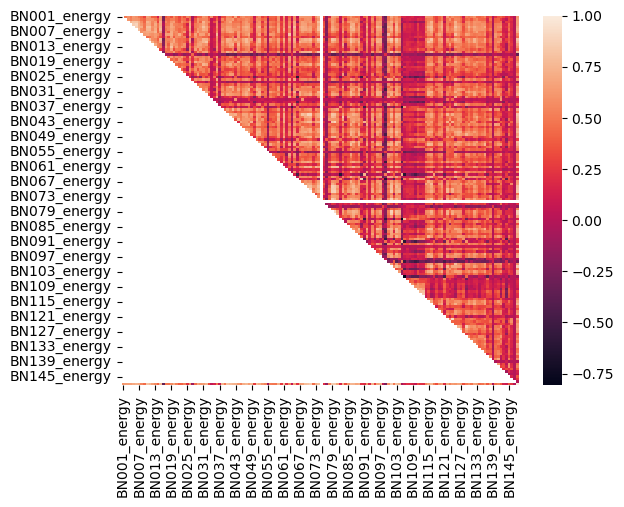

In [ ]:
## triangular matrix to discover triangular correlation ##
il = np.tril_indices(147) # as 147 buildings/variables

triang_corr = corr_mat.copy().to_numpy()
triang_corr[il] = np.nan

triang_corr = pd.DataFrame(triang_corr, columns=corr_mat.columns, index=corr_mat.index)
sns.heatmap(triang_corr)


The triangular correlation is relfected on the BN series only. CN03 remains on straight line which shows that it is not well correlated to the BN variables

This proves very low correlation between any BN device with CN03 (given CN03 is the only CN device remaining after anomaly removal)

<Axes: xlabel='Time', ylabel='BN001_energy'>

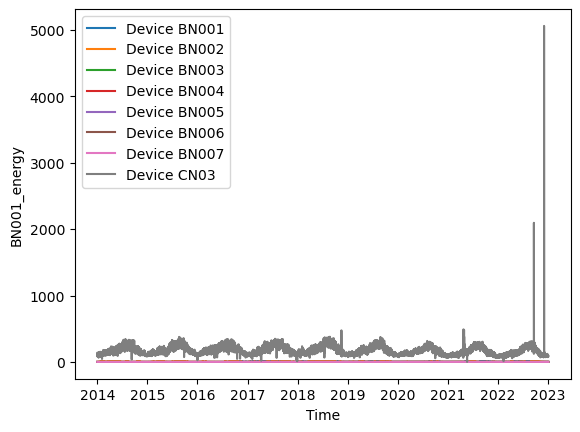

In [202]:
## Decided to Deep dive on the variation of the trend lines between the devices of BN series and CN03 ##

sns.lineplot(data=energy_raw, x=energy_raw.index, y="BN001_energy", label="Device BN001")
sns.lineplot(data=energy_raw, x=energy_raw.index, y="BN002_energy", label="Device BN002")
sns.lineplot(data=energy_raw, x=energy_raw.index, y="BN003_energy", label="Device BN003")
sns.lineplot(data=energy_raw, x=energy_raw.index, y="BN004_energy", label="Device BN004")
sns.lineplot(data=energy_raw, x=energy_raw.index, y="BN005_energy", label="Device BN005")
sns.lineplot(data=energy_raw, x=energy_raw.index, y="BN006_energy", label="Device BN006")
sns.lineplot(data=energy_raw, x=energy_raw.index, y="BN007_energy", label="Device BN007")
sns.lineplot(data=energy_raw, x=energy_raw.index, y="CN03_energy", label="Device CN03")


 


In [137]:
min_val = energy_raw['CN03_energy'].min()
max_val = energy_raw['CN03_energy'].max()

print(f"The minimum value of CN03 is: {min_val}")
print(f"The maximum value of CN03 is: {max_val}")

The minimum value of CN03 is: 0.0
The maximum value of CN03 is: 5058.91


The lineplot shows energy levels for the first 7 devices of the BN series and CN03 that has significant variations. The energy consumption levels of the devices in the BN series are more aligned (values are closer to the 0 range) whereas the values in CN04 seems to have more variation and the numbers are way higher than expected. This indicates that CN03 most likely represents one of the aggregated communities however the min to max range seems a little doubtful. 

Low correlation indicates CN03 does not equal to the total energy consumption of devices in the BN series. CN03's values could be higher due to other possible reasons. 

## Trend Analysis ##

In [153]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

In [154]:
## Scaling the dataframe ##
df_scaled = std_scaler.fit_transform(energy_raw.to_numpy())
energy_df = pd.DataFrame(df_scaled, columns=energy_raw.columns, index=energy_raw.index)
energy_df

,BN001_energy,BN002_energy,BN003_energy,BN004_energy,BN005_energy,BN006_energy,BN007_energy,BN008_energy,BN009_energy,BN010_energy,...,BN139_energy,BN140_energy,BN141_energy,BN142_energy,BN143_energy,BN144_energy,BN145_energy,BN146_energy,BN147_energy,CN03_energy
Time,,,,,,,,,,,,,,,,,,,,,
2014-01-01 00:00:00,NaN,-0.928494,-0.559006,-0.304561,-0.884744,-0.104079,-0.613835,-0.987513,-0.759311,-1.205927,...,-0.276945,-0.206888,-1.055336,NaN,-0.466235,-1.140450,1.124089,NaN,-0.003561,-1.246798
2014-01-01 01:00:00,NaN,-1.012319,-0.705710,-0.106804,-0.984818,-0.104079,-0.613835,-1.036942,-0.720864,-1.180255,...,-0.276945,-0.131916,-1.055336,NaN,-0.466235,-1.146489,1.149776,NaN,-0.003561,-1.291217
2014-01-01 02:00:00,NaN,-0.970407,-0.559006,-0.106804,-0.984818,0.287772,-0.613835,-1.036942,-0.720864,-1.180255,...,-0.276945,-0.311847,-1.038042,NaN,-0.466235,-1.146489,1.175464,NaN,-0.003561,-1.272634
2014-01-01 03:00:00,NaN,-0.980885,-0.559006,-0.106804,-0.984818,-0.104079,-0.613835,-1.036942,-0.759311,-1.180255,...,-0.276945,-0.281859,-0.986157,NaN,-0.466235,-1.146489,1.213994,NaN,-0.003561,-1.256317
2014-01-01 04:00:00,NaN,-0.949450,-0.412301,-0.106804,-0.984818,0.287772,-0.613835,-1.086372,-0.759311,-1.180255,...,-0.276945,-0.251870,-0.986157,NaN,-0.466235,-1.146489,1.342431,NaN,-0.003561,-1.204646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 19:00:00,-0.577401,-0.729410,-1.145824,-1.688859,-1.285039,-1.279632,-0.613835,-1.432379,-0.490180,-0.410095,...,-0.276945,0.227946,-0.138712,-0.672728,-0.359414,2.066252,-0.314397,0.049721,-0.003561,-1.140133
2022-12-31 20:00:00,-0.598889,-0.886582,-1.145824,-1.491102,-1.285039,-0.887781,-0.613835,-1.432379,-0.451732,-0.410095,...,-0.276945,0.092998,-0.138712,-0.940077,-0.359414,2.150797,-0.263023,0.041215,-0.003561,-1.186214
2022-12-31 21:00:00,-0.512934,-0.918016,-1.145824,-1.491102,-1.285039,-0.887781,-0.613835,-1.432379,-0.451732,-0.589799,...,-0.276945,-0.116922,-0.034943,-0.940077,-0.420454,2.199109,-0.237336,0.058227,-0.003561,-1.221416


In [155]:
energy_df = energy_df.reset_index()
energy_df.head()

,Time,BN001_energy,BN002_energy,BN003_energy,BN004_energy,BN005_energy,BN006_energy,BN007_energy,BN008_energy,BN009_energy,...,BN139_energy,BN140_energy,BN141_energy,BN142_energy,BN143_energy,BN144_energy,BN145_energy,BN146_energy,BN147_energy,CN03_energy
0,2014-01-01 00:00:00,NaN,-0.928494,-0.559006,-0.304561,-0.884744,-0.104079,-0.613835,-0.987513,-0.759311,...,-0.276945,-0.206888,-1.055336,NaN,-0.466235,-1.140450,1.124089,NaN,-0.003561,-1.246798
1,2014-01-01 01:00:00,NaN,-1.012319,-0.705710,-0.106804,-0.984818,-0.104079,-0.613835,-1.036942,-0.720864,...,-0.276945,-0.131916,-1.055336,NaN,-0.466235,-1.146489,1.149776,NaN,-0.003561,-1.291217
2,2014-01-01 02:00:00,NaN,-0.970407,-0.559006,-0.106804,-0.984818,0.287772,-0.613835,-1.036942,-0.720864,...,-0.276945,-0.311847,-1.038042,NaN,-0.466235,-1.146489,1.175464,NaN,-0.003561,-1.272634
3,2014-01-01 03:00:00,NaN,-0.980885,-0.559006,-0.106804,-0.984818,-0.104079,-0.613835,-1.036942,-0.759311,...,-0.276945,-0.281859,-0.986157,NaN,-0.466235,-1.146489,1.213994,NaN,-0.003561,-1.256317
4,2014-01-01 04:00:00,NaN,-0.949450,-0.412301,-0.106804,-0.984818,0.287772,-0.613835,-1.086372,-0.759311,...,-0.276945,-0.251870,-0.986157,NaN,-0.466235,-1.146489,1.342431,NaN,-0.003561,-1.204646


In [156]:
## adding month, day of week, day and hour data in a specific format ##
energy_df['monthofyear'] = [str(n).zfill(2)+"-"+m for n,m in zip(energy_df.Time.dt.month, energy_df.Time.dt.month_name())] #extracting month
energy_df["month"] = energy_df.Time.dt.to_period("M")
energy_df["dayofweek"] = [str(n).zfill(2)+"-"+m for n,m in zip(energy_df.Time.dt.dayofweek, energy_df.Time.dt.day_name())] #extracting day of week
energy_df["day"] = energy_df.Time.dt.to_period("D")
energy_df["hour"] = energy_df.Time.dt.to_period("h")
energy_df.head(3)

,Time,BN001_energy,BN002_energy,BN003_energy,BN004_energy,BN005_energy,BN006_energy,BN007_energy,BN008_energy,BN009_energy,...,BN144_energy,BN145_energy,BN146_energy,BN147_energy,CN03_energy,monthofyear,month,dayofweek,day,hour
0,2014-01-01 00:00:00,NaN,-0.928494,-0.559006,-0.304561,-0.884744,-0.104079,-0.613835,-0.987513,-0.759311,...,-1.140450,1.124089,NaN,-0.003561,-1.246798,01-January,2014-01,02-Wednesday,2014-01-01,2014-01-01 00:00
1,2014-01-01 01:00:00,NaN,-1.012319,-0.705710,-0.106804,-0.984818,-0.104079,-0.613835,-1.036942,-0.720864,...,-1.146489,1.149776,NaN,-0.003561,-1.291217,01-January,2014-01,02-Wednesday,2014-01-01,2014-01-01 01:00
2,2014-01-01 02:00:00,NaN,-0.970407,-0.559006,-0.106804,-0.984818,0.287772,-0.613835,-1.036942,-0.720864,...,-1.146489,1.175464,NaN,-0.003561,-1.272634,01-January,2014-01,02-Wednesday,2014-01-01,2014-01-01 02:00


In [ ]:
cols= [i for i in energy_raw.columns if i.startswith(("BN", "CN"))]
cols.append("monthofyear")
cols



#energy_df = energy_df.set_index("Time") ## indexing time again



['BN001_energy',
 'BN002_energy',
 'BN003_energy',
 'BN004_energy',
 'BN005_energy',
 'BN006_energy',
 'BN007_energy',
 'BN008_energy',
 'BN009_energy',
 'BN010_energy',
 'BN011_energy',
 'BN012_energy',
 'BN013_energy',
 'BN014_energy',
 'BN015_energy',
 'BN016_energy',
 'BN017_energy',
 'BN018_energy',
 'BN019_energy',
 'BN020_energy',
 'BN021_energy',
 'BN022_energy',
 'BN023_energy',
 'BN024_energy',
 'BN025_energy',
 'BN026_energy',
 'BN027_energy',
 'BN028_energy',
 'BN029_energy',
 'BN030_energy',
 'BN031_energy',
 'BN032_energy',
 'BN033_energy',
 'BN034_energy',
 'BN035_energy',
 'BN036_energy',
 'BN037_energy',
 'BN038_energy',
 'BN039_energy',
 'BN040_energy',
 'BN041_energy',
 'BN042_energy',
 'BN043_energy',
 'BN044_energy',
 'BN045_energy',
 'BN046_energy',
 'BN047_energy',
 'BN048_energy',
 'BN049_energy',
 'BN050_energy',
 'BN051_energy',
 'BN052_energy',
 'BN053_energy',
 'BN054_energy',
 'BN055_energy',
 'BN056_energy',
 'BN057_energy',
 'BN058_energy',
 'BN059_energy

<Axes: xlabel='monthofyear'>

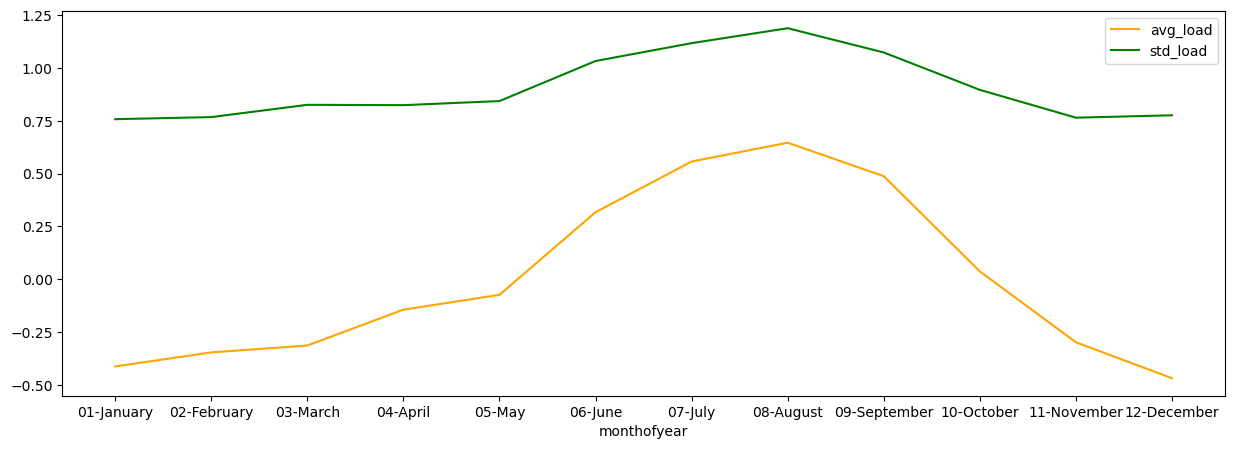

In [ ]:
_monthly = energy_df[cols].melt(id_vars="monthofyear")
monthly =_monthly.rename(columns={"value":"avg_load"})[
    ["monthofyear", "avg_load"]
]
avg_monthly = monthly.groupby("monthofyear").mean()

std_monthly = _monthly.rename(columns={"value":"std_load"})[
    ["monthofyear", "std_load"]
].groupby("monthofyear").std()

fig, ax = plt.subplots(figsize=(15,5))
av_m= sns.lineplot(avg_monthly, palette=["orange"])
sns.lineplot(std_monthly, palette=["green"])


Average energy consumption increases gradually and hitting the peak at august but then dropping at a faster rate from August to December. December hits the 
lowest consumption compared to the all the months throughout the year. 

Incase of std, it remains stead all throughout may with a slow jump in august but again drops down gradually through December.

Overall we can see a bump towards august (starting from May)

<Axes: xlabel='monthofyear'>

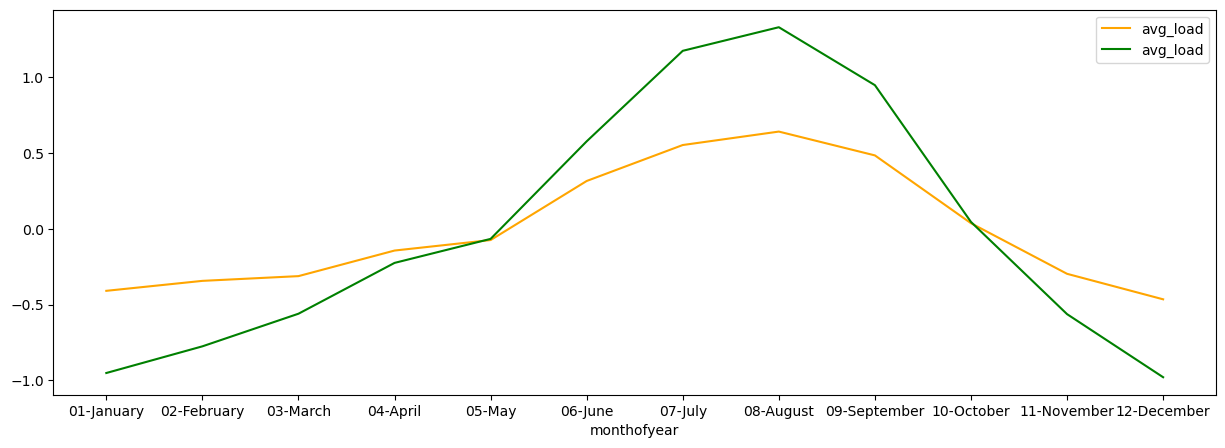

In [ ]:
## Looking into the avg load trend for BN and CN devices separately ##

cols_BN= [i for i in energy_raw.columns if i.startswith(("BN"))]
cols_BN.append("monthofyear")

cols_CN= [i for i in energy_raw.columns if i.startswith(("CN"))]
cols_CN.append("monthofyear")


bn_monthly = energy_df[cols_BN].melt(id_vars="monthofyear")
bn_rename_monthly =bn_monthly.rename(columns={"value":"avg_load"})[
    ["monthofyear", "avg_load"]
]
bn_avg_monthly = bn_rename_monthly.groupby("monthofyear").mean()

cn_monthly = energy_df[cols_CN].melt(id_vars="monthofyear")
cn_rename_monthly =cn_monthly.rename(columns={"value":"avg_load"})[
    ["monthofyear", "avg_load"]
]
cn_avg_monthly = cn_rename_monthly.groupby("monthofyear").mean()


fig, ax = plt.subplots(figsize=(15,5))
av_m= sns.lineplot(bn_avg_monthly, palette=["orange"])
sns.lineplot(cn_avg_monthly, palette=["green"])

The trend here shows how the avg load for BN series has increased starting from May till August. Similarly CN03's energy load increased even though the load amount is significantly high in comparison. This graph shows BN and CN's trends are similar thus proving that CN's value might have some outliers but the readings are not incorrect entirely. 

<Axes: xlabel='month', ylabel='kWh'>

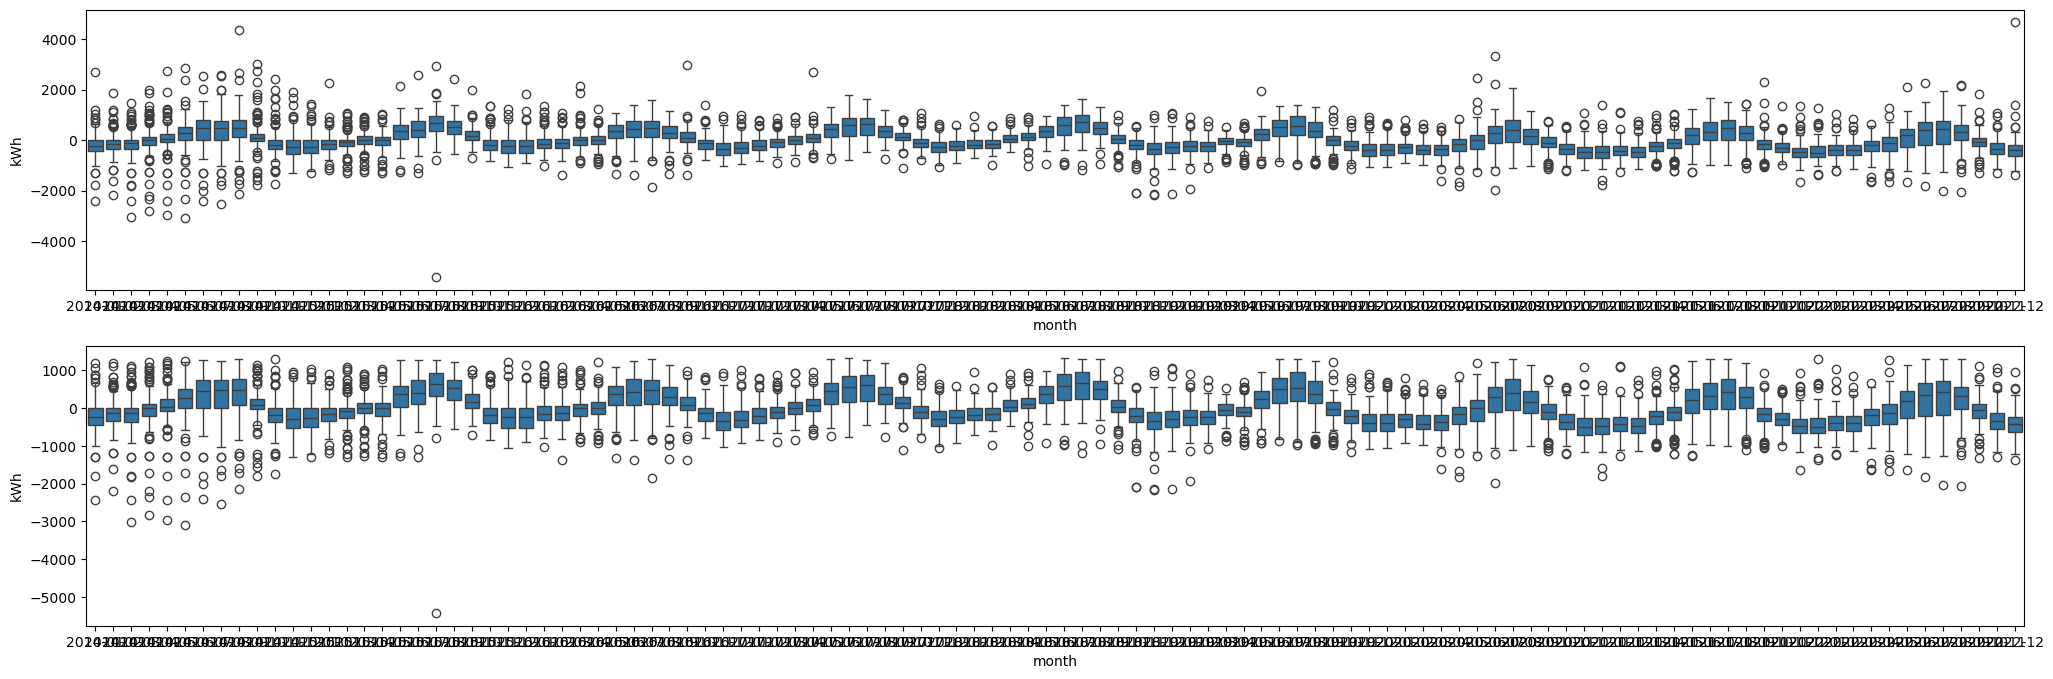

In [ ]:
## Creating box plots ##
cols= [i for i in energy_raw.columns if i.startswith(("BN", "CN"))]
cols.append("month")

monthly_usage = energy_df[cols].groupby("month").sum().reset_index()
monthly_usage = monthly_usage.melt(id_vars="month").rename(columns={"variable": "meter_id", "value":"kWh"})
palette= sns.color_palette(['black'])

fig, ax = plt.subplots(figsize = (25,8), nrows = 2)
threshold = monthly_usage.kWh.quantile(0.99) #what counts as an extreme value
sns.boxplot(monthly_usage, x="month", y="kWh", ax=ax[0])
sns.boxplot(monthly_usage[monthly_usage.kWh<threshold], x="month", y="kWh", ax=ax[1])


Since its a big dataset, we can notice a significant amount of outliers in the dataset indicates that there is a high variability on the data and contains some negative consumption data as well. As seen previously on the line graphs, we can also observe rise across every year (possibly around May to August). It can be due to the season as consumption can be high during spring/summer. Specifically, the meter values (some represents negative values) can be considered as meter error or anomalies which needs to be sanitized. 

<Axes: xlabel='dayofweek', ylabel='kWh'>

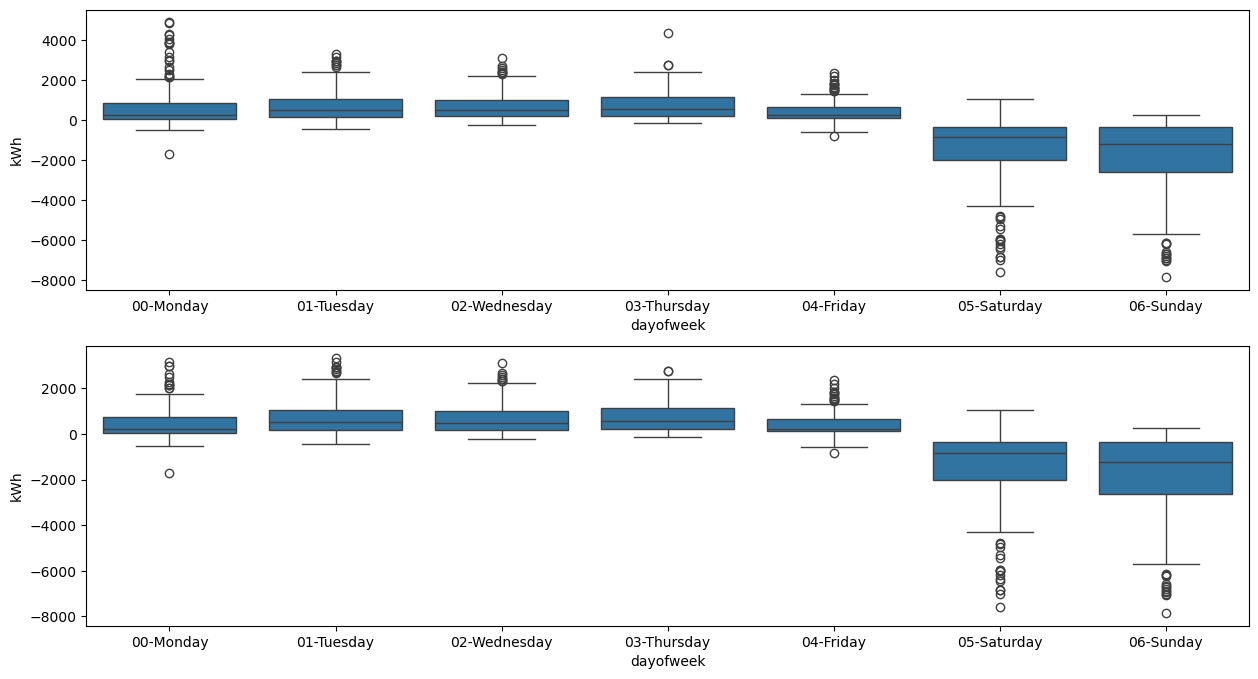

In [ ]:
cols= [i for i in energy_raw.columns if i.startswith(("BN", "CN"))]
cols.append("dayofweek")

monthly_usage = energy_df[cols].groupby("dayofweek").sum().reset_index()
monthly_usage = monthly_usage.melt(id_vars="dayofweek").rename(columns={"variable": "meter_id", "value":"kWh"})
palette= sns.color_palette(['black'])

fig, ax = plt.subplots(figsize = (15,8), nrows = 2)
threshold = monthly_usage.kWh.quantile(0.99) #what counts as an extreme value
sns.boxplot(monthly_usage, x="dayofweek", y="kWh", ax=ax[0])
sns.boxplot(monthly_usage[monthly_usage.kWh<threshold], x="dayofweek", y="kWh", ax=ax[1])


The consumption of energy has been very consistent throughout the weekday (even though some outliers can be seen) on the weekend, we see a slight drop compared to weekdays. Sunday seems to have high variation of energy consumption compared to Saturday. As above, negative values can be observed here as well.

## Data Sanitization ## 

In [196]:
energy_clean = energy_raw.copy()
device_cols = [col for col in energy_clean.columns if col.startswith(('BN', 'CN'))]

device_cols

energy_clean[device_cols] = energy_clean[device_cols].mask(energy_clean[device_cols] <= 0)

for col in device_cols:
        upper_limit = energy_clean[col].quantile(0.99)
        energy_clean[col] = energy_clean[col].clip(upper=upper_limit)

energy_clean[device_cols] = energy_clean[device_cols].interpolate(method='time')

energy_clean[device_cols] = energy_clean[device_cols].ffill().bfill()

energy_clean.head()

,BN001_energy,BN002_energy,BN003_energy,BN004_energy,BN005_energy,BN006_energy,BN007_energy,BN008_energy,BN009_energy,BN010_energy,...,BN139_energy,BN140_energy,BN141_energy,BN142_energy,BN143_energy,BN144_energy,BN145_energy,BN146_energy,BN147_energy,CN03_energy
Time,,,,,,,,,,,,,,,,,,,,,
2014-01-01 00:00:00,2.26,1.26,0.10,0.10,0.12,0.04,0.02,0.31,0.17,0.20,...,0.03,0.75,0.29,0.2,0.17,0.14,2.02,0.37,2.21,89.35
2014-01-01 01:00:00,2.26,1.18,0.09,0.11,0.11,0.04,0.02,0.30,0.18,0.21,...,0.03,0.80,0.29,0.2,0.17,0.13,2.04,0.37,2.26,86.41
2014-01-01 02:00:00,2.26,1.22,0.10,0.11,0.11,0.05,0.02,0.30,0.18,0.21,...,0.03,0.68,0.30,0.2,0.17,0.13,2.06,0.37,2.15,87.64
2014-01-01 03:00:00,2.26,1.21,0.10,0.11,0.11,0.04,0.02,0.30,0.17,0.21,...,0.03,0.70,0.33,0.2,0.17,0.13,2.09,0.37,2.20,88.72
2014-01-01 04:00:00,2.26,1.24,0.11,0.11,0.11,0.05,0.02,0.29,0.17,0.21,...,0.03,0.72,0.33,0.2,0.17,0.13,2.19,0.37,2.23,92.14


## Predictive Modelling ##

In [198]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

hourly_profiles = energy_clean[device_cols].groupby(energy_clean.index.hour).mean().T

scaler= MinMaxScaler()
scaled_profiles = scaler.fit_transform(hourly_profiles.T).T
scaled_profiles_df = pd.DataFrame(scaled_profiles, index=device_cols)

scaled_profiles_df.head()

c:\Users\malih\anaconda3\Lib\site-packages\sklearn\utils\_array_api.py:701: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\malih\anaconda3\Lib\site-packages\sklearn\utils\_array_api.py:718: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
BN001_energy,0.052645,0.027854,0.000000,0.055066,0.017499,0.016635,0.110936,0.377365,0.500469,0.620040,...,0.981438,0.981280,1.000000,0.969216,0.858131,0.734156,0.611104,0.510659,0.245685,0.085064
BN002_energy,0.155666,0.109297,0.076970,0.037886,0.004875,0.000000,0.196044,0.249518,0.324580,0.480578,...,0.959287,0.994565,1.000000,0.945986,0.828736,0.707533,0.601516,0.512403,0.417760,0.284170
BN003_energy,0.050430,0.025813,0.009883,0.004577,0.000000,0.050854,0.124446,0.236421,0.332621,0.452913,...,0.980348,1.000000,0.972343,0.855667,0.602394,0.425608,0.347930,0.272296,0.168736,0.086458
BN004_energy,0.092745,0.062882,0.037257,0.013088,0.000000,0.030724,0.073161,0.194063,0.358902,0.492694,...,0.972402,1.000000,0.942644,0.760803,0.549320,0.370208,0.283444,0.226300,0.159842,0.121195
BN005_energy,0.074014,0.053426,0.035614,0.013283,0.000000,0.028278,0.225643,0.316433,0.496811,0.621639,...,0.957922,1.000000,0.984908,0.845702,0.637274,0.463425,0.361943,0.287018,0.188478,0.099907


In [197]:
# Drop Nans

scaled_profiles_df = scaled_profiles_df.dropna()

# Double check for Infinite values (just in case)
scaled_profiles_df = scaled_profiles_df.replace([np.inf, -np.inf], np.nan).dropna()


c:\Users\malih\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\malih\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\malih\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\malih\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

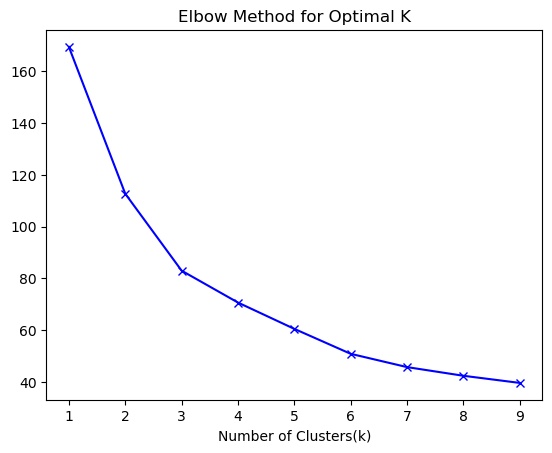

In [176]:
inertia = []
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_profiles_df)
    inertia.append(km.inertia_)

plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters(k)')
plt.title('Elbow Method for Optimal K')
plt.show()

Based on the elbow method graph, the elbow seem to appear when k=3, revealing 3 possible clusters for this dataset. 

In [ ]:
## Looking into where CN03 lies in the cluster ##
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters=kmeans.fit_predict(scaled_profiles_df)

cluster_mapping = pd.DataFrame({
    'meter_id': scaled_profiles_df.index,
    'cluster_label': clusters
})

print(cluster_mapping[cluster_mapping['meter_id'] == 'CN03_energy'])


        meter_id  cluster_label
146  CN03_energy              2


c:\Users\malih\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


CN03 falls under cluster 2

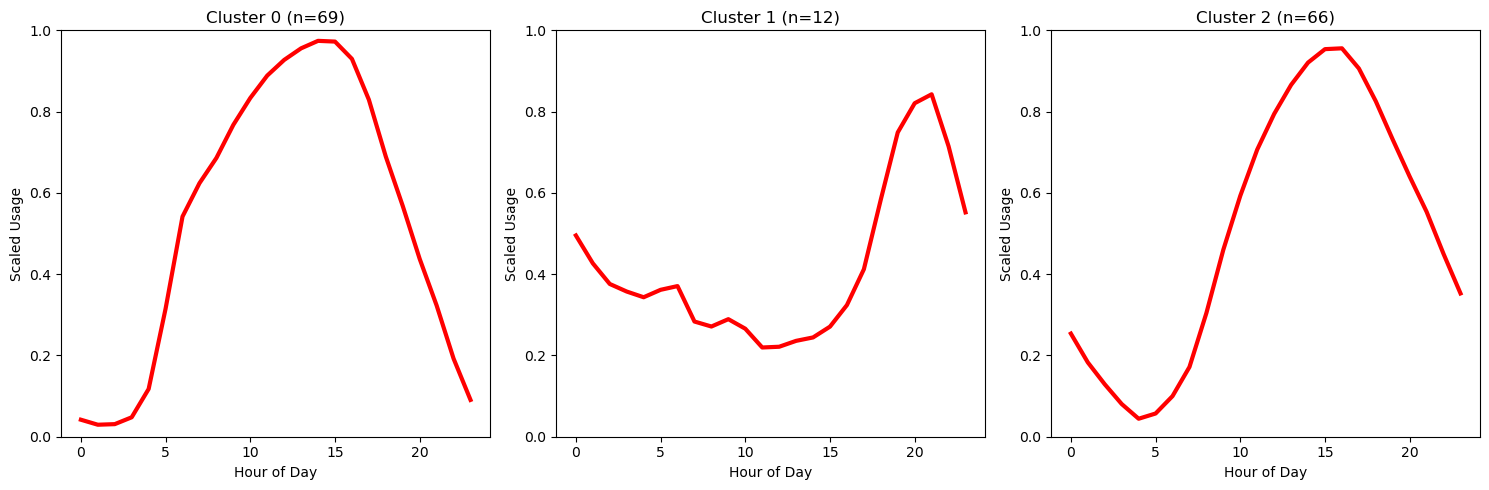

In [ ]:
## Trend of each cluster ##
plt.figure(figsize=(15,5))
for i in range(3):
    plt.subplot(1,3, i+1)
    meters = cluster_mapping[cluster_mapping['cluster_label'] == i]['meter_id']

    plt.plot(kmeans.cluster_centers_[i], color='red', linewidth=3)
    plt.title(f"Cluster {i} (n={len(meters)})")
    plt.xlabel("Hour of Day")
    plt.ylabel("Scaled Usage")
    plt.ylim(0,1)

plt.tight_layout()
plt.show()

The 3 clusters show different behavior throughout 24 hours. 

In Cluster 0 we can see the energy ramping up from 4 or 5am and peaks around 13th hour (1pm). This represents usage during the day (possible Standard Building load). 

In Cluster 1, the graph seems to scale up at midnight but the remains low during the day which implies high usage midnight (possibly security loads). 

However in Cluster 2 is where CN03 lies. The curve is seen to be more wider and smoother than cluster 0. It could possibly indicate the consumption by heavy systems or large-scale infrastructure that serves multiple buildings. 

In [ ]:
## Data Aggregation for each clusters ##
cluster_signals = pd.DataFrame(index=energy_clean.index)

for i in range(3):
    cluster_meters = cluster_mapping[cluster_mapping['cluster_label'] == i]['meter_id']
    cluster_signals[f'Clusters{i}_Total'] = energy_clean[cluster_meters].sum(axis=1)

cluster_signals.head()

,Clusters0_Total,Clusters1_Total,Clusters2_Total
Time,,,
2014-01-01 00:00:00,27.280,24.15,157.45
2014-01-01 01:00:00,27.269,23.95,152.38
2014-01-01 02:00:00,27.318,25.14,153.37
2014-01-01 03:00:00,27.327,25.21,155.22
2014-01-01 04:00:00,28.976,28.39,159.17


In [194]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error

def create_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['is_weekend'] = df.index.dayofweek.isin([5,6]).astype(int)
    return df

X = create_features(cluster_signals)
X_features = X[['hour', 'dayofweek', 'month', 'is_weekend']]

models= {}
predictions_df = pd.DataFrame(index=cluster_signals.index)

print("Starting Cluster-Level Modeling:")

for i in range(3):
    target_col = f'Clusters{i}_Total'
    y = cluster_signals[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, shuffle=False)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    models[i] = model

    test_preds = model.predict(X_test)

    score = mean_absolute_percentage_error(y_test, test_preds)
    print(f"Cluster {i} Model trained. Error Rate: {score:.2%}")

    predictions_df.loc[y_test.index, f'Cluster_{i}_Actual'] = y_test
    predictions_df.loc[y_test.index, f'Cluster_{i}_Pred'] = test_preds


Starting Cluster-Level Modeling:
Cluster 0 Model trained. Error Rate: 14.26%
Cluster 1 Model trained. Error Rate: 65.38%
Cluster 2 Model trained. Error Rate: 18.20%


Cluster 0: error rate is low, likely human errors present. So mostly reliable group.

Cluster 1: It has significant error rate (above 50 percent). The 12 meters present in this cluster might have some issues e.g faulty sensors. 

Cluster 2: error rate is a little higher than cluster 0 but considering that it represents heavy systems consumption, the rate is not bad. There could be some mechanical degradation that could cause this rate or due to weather (incase of thermal energy demand).

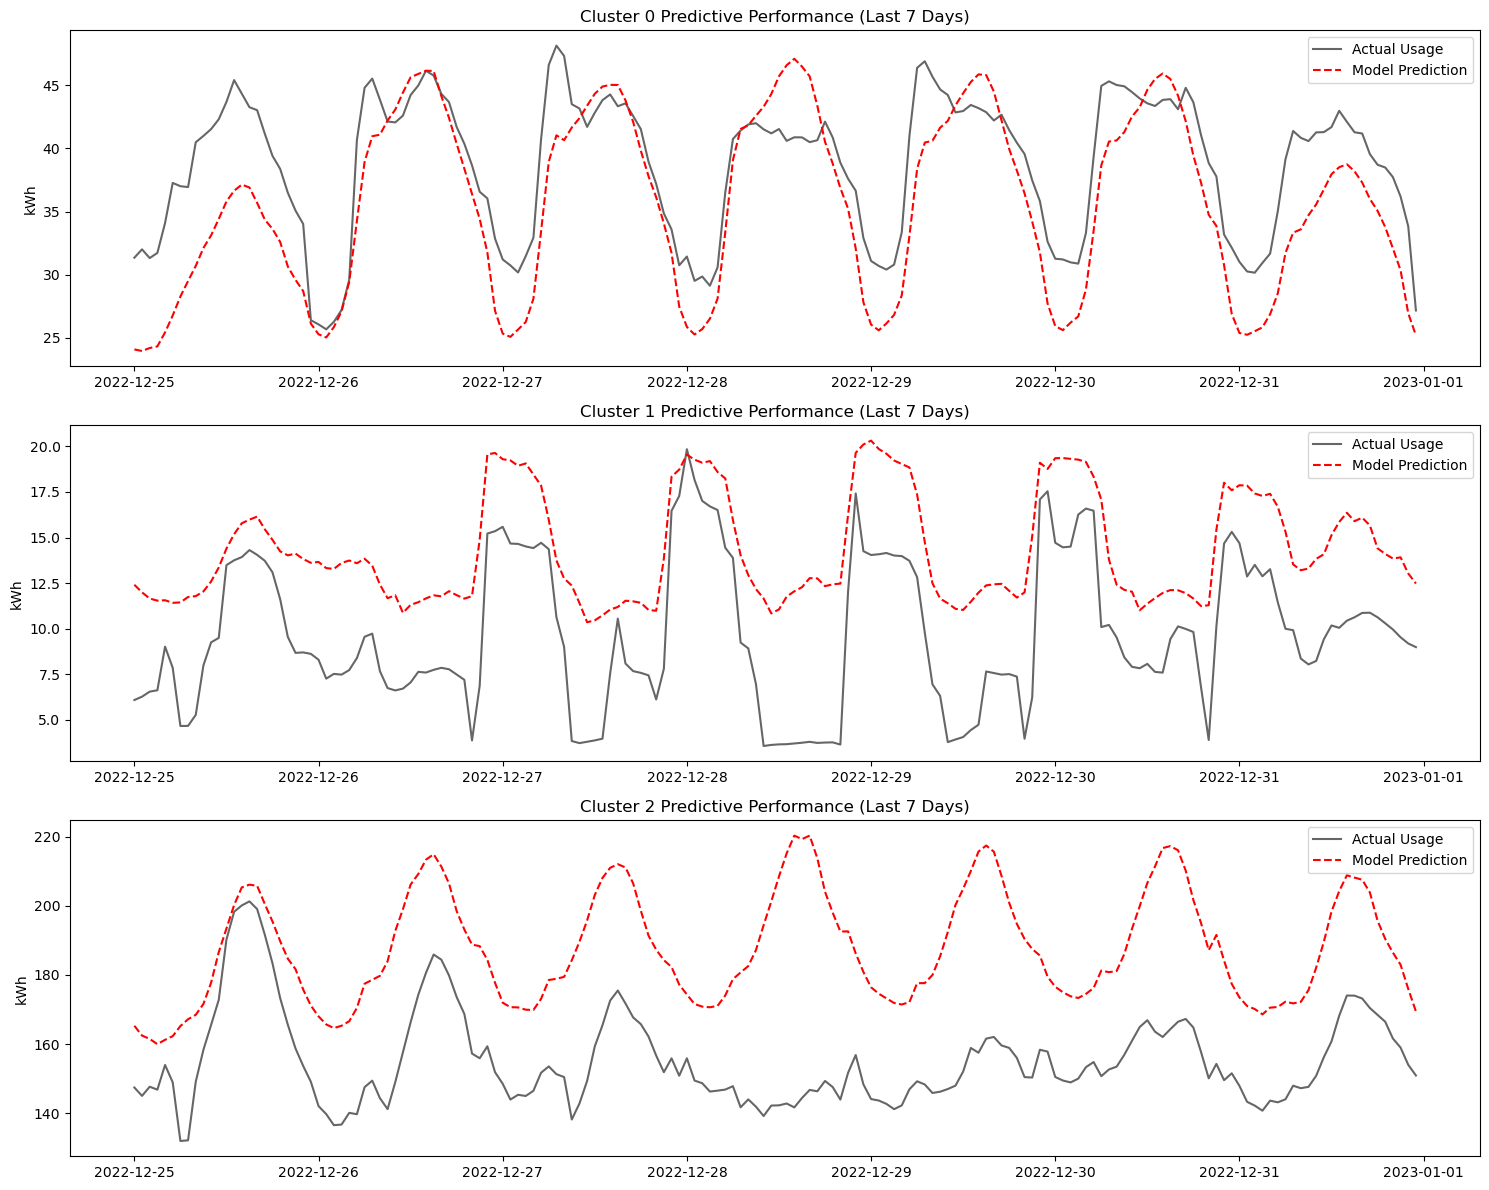

In [195]:
## Sneak peak of the predictive performance in the last 7 days ##
plt.figure(figsize=(15, 12))

for i in range(3):
    plt.subplot(3, 1, i+1)
    # Plotting only the last 7 days of the test set so we can actually see the lines
    recent_data = predictions_df.tail(24*7) 
    
    plt.plot(recent_data[f'Cluster_{i}_Actual'], label='Actual Usage', color='black', alpha=0.6)
    plt.plot(recent_data[f'Cluster_{i}_Pred'], label='Model Prediction', color='red', linestyle='--')
    
    plt.title(f'Cluster {i} Predictive Performance (Last 7 Days)')
    plt.legend()
    plt.ylabel('kWh')

plt.tight_layout()
plt.show()

Cluster 0 has healthy baseline. Aligns well with the prediction. 

Cluster 1 has major gap between predicted and actual lines. Given the 65% error rate, there is heavy fluctuation when compared to the predicted line. It requires further investigation. 

Cluster 2 has a major difference between predicted and actual as well where actual is significantly lower than the predicted trendline. Probably the heavy systems are underperforming or not being operated as expected. 

In [ ]:
## Anomaly Detection ##
anomaly_summary = {}

for i in range(3):
    actual_col = f'Cluster_{i}_Actual'
    pred_col = f'Cluster_{i}_Pred'
    error_col = f'C{i}_Error'
    anomaly_col = f'C{i}_Anomaly'
    
    #Absolute error
    predictions_df[error_col] = (predictions_df[actual_col] - predictions_df[pred_col]).abs()
    
    #Threshold
    threshold = predictions_df[error_col].mean() + (2 * predictions_df[error_col].std())
    
    #Anomaly
    predictions_df[anomaly_col] = predictions_df[error_col] > threshold
    
    #Count
    anomaly_summary[f"Cluster {i}"] = predictions_df[anomaly_col].sum()

print("Anomaly Report:")
for cluster, count in anomaly_summary.items():
    print(f"{cluster}: {count} anomalies detected")

Anomaly Report:
Cluster 0: 897 anomalies detected
Cluster 1: 587 anomalies detected
Cluster 2: 659 anomalies detected


Cluster 0: It has the highest number of anomalies but not a red flag as there are 69 meters in this clusters. Most anomalies in this cluster could be operational inefficiencies. 

Cluster 1: Given that it has 65% error rate, 587 anomalies is significantly high for this cluster (also given that there are only 12 meters in this cluster). This indicates that the meters in this cluster are most likely faulty or programmed incorrectly. These meters/sensors are required to be examined. 

Cluster 2: It also presents signicant number anomalies (still better than cluster 1) but it means that the big systems has some issues that need to looked at as well. There could be a possibility that the systems are not being operated with stability for example, it could be underperforming, running longer than it should, or shutting down when they should be running. The infrastructure needs to be assessed.